# EDA — Modelo de predicción Mundial 2026

Análisis exploratorio del dataset que alimenta el modelo de clasificación
multiclase `[Away Win, Draw, Home Win]` y la simulación Monte Carlo del
torneo. Las interpretaciones de cada sección están basadas en los números
concretos producidos por las celdas; no se asumen patrones genéricos.


## 1. Setup


In [1]:
import os
import sys
from pathlib import Path

# CWD = project root
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    os.chdir(_repo_root.parent)
    _repo_root = Path.cwd()
sys.path.insert(0, str(_repo_root))

print(f"CWD: {_repo_root}")

CWD: C:\Users\david\Desktop\fifa-world-cup-model


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_palette("colorblind")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

FIG_DIR = Path("reports") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str):
    out = FIG_DIR / f"eda_{name}.png"
    plt.savefig(out)
    print(f"  -> {out}")


from src.features.features import FEATURE_COLS, DERIVED_FEATURE_COLS
from src.features.time_decay import (
    REFERENCE_DATE, SNAPSHOT_DATE, lambda_to_halflife_years, DEFAULT_LAMBDA,
)
print(f"FEATURE_COLS ({len(FEATURE_COLS)}) = {FEATURE_COLS}")
print(f"  derivadas = {DERIVED_FEATURE_COLS}")
print(f"REFERENCE_DATE = {REFERENCE_DATE.date()} (horizonte de decay)")
print(f"SNAPSHOT_DATE  = {SNAPSHOT_DATE.date()} (as-of de features por equipo)")


FEATURE_COLS (9) = ['elo_diff', 'squad_value_diff', 'xg_avg_for', 'xg_avg_against', 'travel_distance_diff', 'ranking_diff', 'penalty_share_diff', 'striker_concentration_diff', 'shootout_winrate_diff']
  derivadas = ['penalty_share_diff', 'striker_concentration_diff', 'shootout_winrate_diff']
REFERENCE_DATE = 2026-01-01 (horizonte de decay)
SNAPSHOT_DATE  = 2026-05-30 (as-of de features por equipo)


## 2. Inventario de fuentes de datos

El pipeline combina resultados históricos, datos de eventos (goleadores y
tandas de penales), ranking FIFA (serie histórica + snapshot 2026), xG y valor
de plantilla.


In [3]:
from src.data.data_loader import (
    load_international_results, load_fifa_ranking, load_fifa_rankings_2026,
    load_wc2026_fixture, filter_relevant_matches,
    load_goalscorers, load_shootouts,
)
from src.data.scraper import (
    get_statsbomb_xg_by_team, get_squad_values, SQUAD_VALUES_SNAPSHOT_DATE,
)

# 1. International results (martj42) - universo completo para ELO
results_raw = load_international_results()
print(f"international_results: {len(results_raw):,} filas, "
      f"{results_raw['date'].dt.year.min()}-{results_raw['date'].dt.year.max()}")

# 2. FIFA ranking (serie histórica hasta 2024-06 + snapshot 2026-05-30 anexado)
fifa = load_fifa_ranking()
snap2026 = load_fifa_rankings_2026()
print(f"fifa_ranking: {len(fifa):,} filas, {fifa['team'].nunique()} equipos, "
      f"hasta {fifa['rank_date'].max().date()} | snapshot 2026: {len(snap2026)} equipos")

# 3. Fixture WC 2026
fixture = load_wc2026_fixture()
print(f"wc2026_fixture: {len(fixture)} equipos en {fixture['group'].nunique()} grupos")

# 4. Datos de eventos (features derivadas as-of-date)
goalscorers = load_goalscorers()
shootouts = load_shootouts()
print(f"goalscorers: {len(goalscorers):,} goles | shootouts: {len(shootouts):,} tandas")

# 5. xG StatsBomb
try:
    xg = get_statsbomb_xg_by_team()
    print(f"statsbomb_xg: {len(xg)} equipos con xG")
except Exception as e:
    print(f"statsbomb_xg no disponible: {e}")
    xg = pd.DataFrame()

# 6. Squad values (snapshot manual)
squad = get_squad_values()
print(f"squad_values: {len(squad)} equipos (snapshot {SQUAD_VALUES_SNAPSHOT_DATE})")


international_results: 49,329 filas, 1872-2026


fifa_ranking: 67,683 filas, 216 equipos, hasta 2026-05-30 | snapshot 2026: 211 equipos
wc2026_fixture: 48 equipos en 12 grupos


goalscorers: 47,601 goles | shootouts: 677 tandas


statsbomb_xg: 109 equipos con xG
  squad_values.csv cargado desde caché (62 equipos)
squad_values: 62 equipos (snapshot 2026-05)


In [4]:
inventory = pd.DataFrame([
    {"fuente": "international_results", "filas": len(results_raw),
     "rango": f"{results_raw['date'].dt.year.min()}-{results_raw['date'].dt.year.max()}",
     "equipos": pd.concat([results_raw['home_team'], results_raw['away_team']]).nunique()},
    {"fuente": "fifa_ranking (+snapshot)", "filas": len(fifa),
     "rango": f"1992-{fifa['rank_date'].max().year}", "equipos": fifa['team'].nunique()},
    {"fuente": "goalscorers", "filas": len(goalscorers),
     "rango": f"{goalscorers['date'].dt.year.min()}-{goalscorers['date'].dt.year.max()}",
     "equipos": goalscorers['team'].nunique()},
    {"fuente": "shootouts", "filas": len(shootouts),
     "rango": f"{shootouts['date'].dt.year.min()}-{shootouts['date'].dt.year.max()}",
     "equipos": pd.concat([shootouts['home_team'], shootouts['away_team']]).nunique()},
    {"fuente": "wc2026_fixture", "filas": len(fixture), "rango": "2026", "equipos": fixture['team'].nunique()},
    {"fuente": "statsbomb_xg", "filas": len(xg), "rango": "UEFA/FIFA OpenData", "equipos": len(xg)},
    {"fuente": "squad_values", "filas": len(squad), "rango": SQUAD_VALUES_SNAPSHOT_DATE, "equipos": len(squad)},
])
inventory


,fuente,filas,rango,equipos
0,international_results,49329,1872-2026,334
1,fifa_ranking (+snapshot),67683,1992-2026,216
2,goalscorers,47601,1916-2026,218
3,shootouts,677,1967-2026,228
4,wc2026_fixture,48,2026,48
5,statsbomb_xg,109,UEFA/FIFA OpenData,109
6,squad_values,62,2026-05,62


- `international_results` aporta el grueso del volumen (~49 k partidos, 334
  selecciones) y es la única fuente con datos pre-1990 — base para calcular el
  ELO histórico desde 1872 (todos los torneos, incl. amistosos).
- `fifa_ranking` (67.7 k filas, 216 equipos) cubre 1992–2024 en serie mensual,
  **extendida con el snapshot del 2026-05-30** (211 equipos) para refrescar el
  ranking.
- `goalscorers` (47.6 k goles, 1916–2026) y `shootouts` (677 tandas, 1967–2026)
  alimentan las features derivadas as-of-date (penal, concentración de
  goleadores, winrate en tandas).
- `statsbomb_xg` cubre solo 109 equipos — adelanta una limitación (sección 9):
  los xG son escasos para confederaciones AFC, CAF y CONCACAF.
- `squad_values` cubre 62 equipos (snapshot mayo 2026). Coincide con los 48 del
  Mundial, pero deja huecos para selecciones históricas usadas en entrenamiento.


## 3. Calidad de datos


In [5]:
from src.features.features import data_quality_report
data_quality_report(results_raw, "international_results crudo")



=== Data quality report: international_results crudo ===
  Filas: 49,329
  Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
  Nulos por columna:
    home_score: 72
    away_score: 72
  Duplicados exactos: 0
  Rango de fechas: 1872-11-30 - 2026-06-27
  Equipos únicos en home_team: 325
  Equipos únicos en away_team: 319



In [6]:
# Filtrado al subset que el modelo EMITE como filas (torneos relevantes,
# year >= OUTPUT_ROW_START_YEAR = 1993). El ELO, en cambio, usa el universo
# completo sin filtrar (ver sección 7).
results = filter_relevant_matches(results_raw)  # default year_cutoff = 1993
data_quality_report(results, "international_results filtrado (filas a emitir)")



=== Data quality report: international_results filtrado (filas a emitir) ===
  Filas: 12,229
  Columnas: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
  Nulos por columna:
    home_score: 72
    away_score: 72
  Duplicados exactos: 0
  Rango de fechas: 1993-01-10 - 2026-06-27
  Equipos únicos en home_team: 217
  Equipos únicos en away_team: 217



- Crudo: 49,329 partidos, 1872-2026, **72 nulos** en `home_score`/`away_score`
  (partidos pendientes del año en curso) y **0 duplicados exactos**.
- Tras filtrar por torneos relevantes y `year_cutoff=1993`: quedan **12,229
  partidos** y **217 equipos**. La reducción es grande porque se descartan
  amistosos y torneos menores que el modelo no emite como filas.
- **Importante:** este filtrado solo define las *filas a emitir*. El ELO se
  calcula sobre el universo completo sin filtrar (sección 7), de modo que
  amistosos e historia pre-1993 sí contribuyen al rating.


  -> reports\figures\eda_03_top_tournaments.png


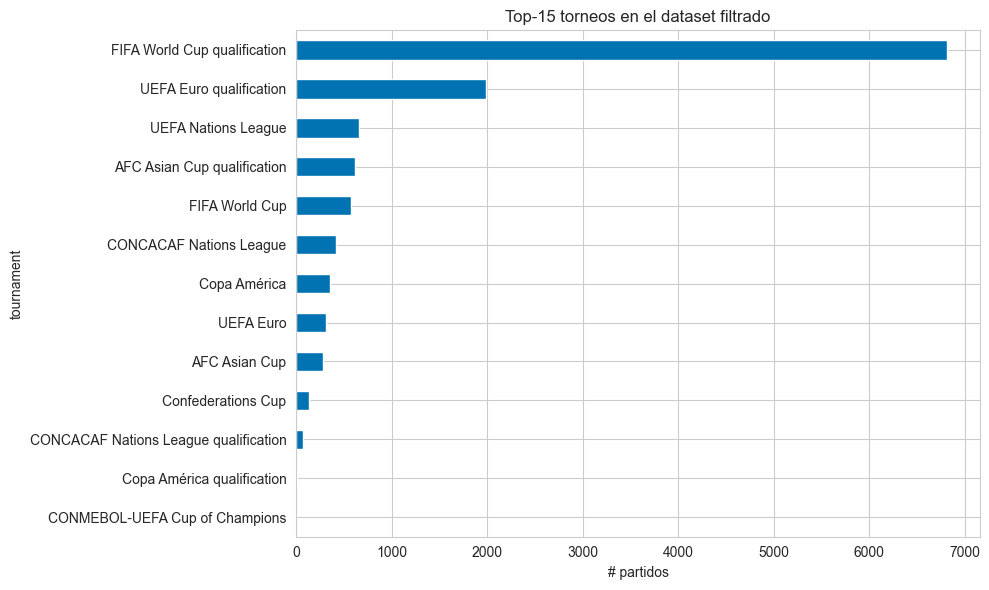

In [7]:
# Distribución por torneo (top 15)
top_tournaments = results['tournament'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_tournaments.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel("# partidos")
ax.set_title("Top-15 torneos en el dataset filtrado")
plt.tight_layout()
savefig("03_top_tournaments")
plt.show()


  -> reports\figures\eda_03_matches_per_year.png


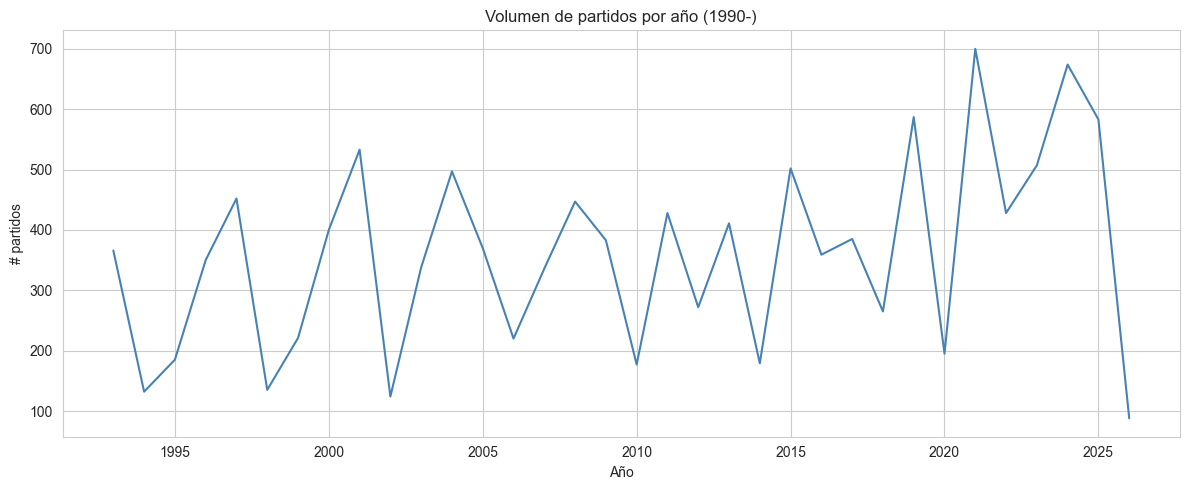

In [8]:
# Distribución de partidos por año
fig, ax = plt.subplots(figsize=(12, 5))
results.groupby(results['date'].dt.year).size().plot(ax=ax, color='steelblue')
ax.set_xlabel("Año")
ax.set_ylabel("# partidos")
ax.set_title("Volumen de partidos por año (1990-)")
plt.tight_layout()
savefig("03_matches_per_year")
plt.show()


In [9]:
# Cobertura por equipo
team_counts = pd.concat([results['home_team'], results['away_team']]).value_counts()
print(f"Total equipos en el dataset filtrado: {len(team_counts)}")
print(f"\nTop-10 equipos con más partidos:")
print(team_counts.head(10).to_string())
print(f"\nBottom-10 equipos con menos partidos:")
print(team_counts.tail(10).to_string())


Total equipos en el dataset filtrado: 217

Top-10 equipos con más partidos:
Spain          273
Italy          266
Argentina      265
Brazil         265
Portugal       263
Uruguay        256
Germany        256
Mexico         254
France         250
Netherlands    249

Bottom-10 equipos con menos partidos:
Somalia                  21
Tonga                    20
São Tomé and Príncipe    20
Comoros                  20
Martinique               20
Cook Islands             18
American Samoa           15
South Sudan              14
Vanuatu                  13
Eritrea                  10


- Los 10 más activos (Spain 273, Italy 266, Argentina 265, Brazil 265,
  Portugal 263, ...) tienen entre 250 y 275 partidos relevantes en ~33 años —
  consistente con un calendario UEFA / Eliminatorias + Eurocopas / Mundial.
- En el otro extremo, las selecciones pequeñas (Eritrea 10, Vanuatu 13,
  South Sudan 14, American Samoa 15, ...) tienen muestras insuficientes para
  estimación ELO confiable. Cualquier predicción sobre estos equipos hereda un
  ELO cercano al `INITIAL_RATING=1500` (aunque, al usar la historia completa,
  los amistosos ayudan a alejarlos del valor inicial).


## 4. Distribución del target


In [10]:
features = pd.read_csv("data/processed/features.csv", parse_dates=["date"])
print(f"features.csv: {len(features):,} filas, columnas {list(features.columns)}")
features.head()


features.csv: 12,157 filas, columnas ['date', 'home_team', 'away_team', 'elo_diff', 'squad_value_diff', 'xg_avg_for', 'xg_avg_against', 'travel_distance_diff', 'ranking_diff', 'penalty_share_diff', 'striker_concentration_diff', 'shootout_winrate_diff', 'time_weight', 'target']


,date,home_team,away_team,elo_diff,squad_value_diff,xg_avg_for,xg_avg_against,travel_distance_diff,ranking_diff,penalty_share_diff,striker_concentration_diff,shootout_winrate_diff,time_weight,target
0,1993-01-10,Angola,Zimbabwe,-167.520279,0.000000,0.000000,0.000000,0.0,-48.0,0.000000,-0.059707,0.044872,0.000006,1
1,1993-01-10,DR Congo,Cameroon,-112.334065,-0.280622,0.177752,-0.647610,0.0,-38.0,-0.003917,-0.016055,0.071770,0.000006,0
2,1993-01-16,South Africa,Nigeria,-153.844158,-1.114924,0.073391,-0.165729,0.0,-111.0,-0.039370,0.970178,-0.125000,0.000006,1
3,1993-01-16,Tanzania,Zambia,-214.964889,0.000000,0.000000,0.000000,0.0,-48.0,-0.023810,0.100624,-0.115385,0.000006,0
4,1993-01-17,Benin,Tunisia,-332.441451,0.801218,-0.032790,-0.642709,0.0,-89.0,-0.038462,0.300131,-0.038462,0.000006,0


   clase  count   pct
Away Win   3722 30.62
    Draw   2542 20.91
Home Win   5893 48.47


  -> reports\figures\eda_04_target_distribution.png


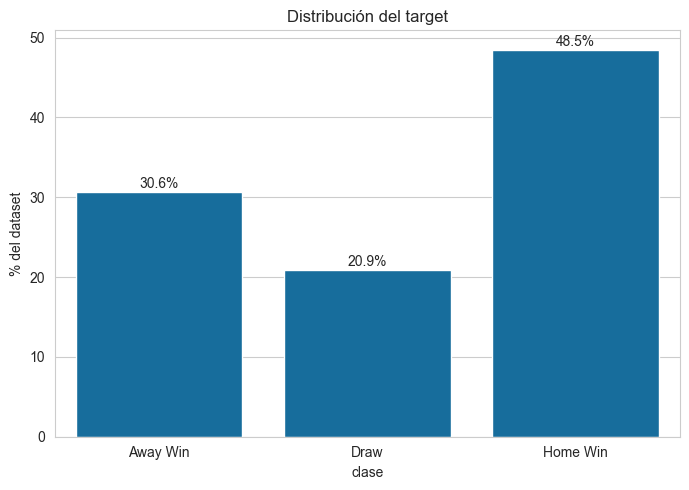

In [11]:
target_map = {0: "Away Win", 1: "Draw", 2: "Home Win"}
target_counts = features['target'].value_counts().sort_index()
target_pct = (target_counts / target_counts.sum() * 100).round(2)
dist = pd.DataFrame({"clase": [target_map[i] for i in target_counts.index],
                     "count": target_counts.values, "pct": target_pct.values})
print(dist.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=dist, x='clase', y='pct', ax=ax)
for i, v in enumerate(dist['pct']):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')
ax.set_ylabel("% del dataset")
ax.set_title("Distribución del target")
plt.tight_layout()
savefig("04_target_distribution")
plt.show()


**Desbalance observado.**

Sobre 12,157 partidos con features completas:

| Clase    | Conteo | %      |
|----------|--------|--------|
| Home Win | 5,893  | 48.47% |
| Away Win | 3,722  | 30.62% |
| Draw     | 2,542  | 20.91% |

1. Home Win representa casi la mitad del dataset: un clasificador que prediga
   "Home Win" siempre lograría accuracy ≈ 48% sin aprender nada. Por eso se
   exige Log-Loss y Brier en lugar de accuracy.
2. Draw es la clase minoritaria con un factor 2.3× respecto a Home Win -
   sin `class_weight="balanced"` el modelo tiende a infra-predecir empates


## 5. Análisis univariado por feature

Las celdas reutilizan `plot_feature_distribution` para mostrar histograma KDE
por clase + boxplot.

In [12]:
def plot_feature_distribution(df, feature, name_slug):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_plot = df.copy()
    df_plot['Resultado'] = df_plot['target'].map(target_map)

    # Disable KDE if any class group has zero variance (e.g. all-zero travel distances)
    use_kde = df_plot.groupby('Resultado')[feature].std().gt(0).all()

    sns.histplot(data=df_plot, x=feature, hue='Resultado',
                 kde=use_kde, bins=40, ax=axes[0], alpha=0.5)
    axes[0].set_title(f"Distribución de {feature} por resultado")

    sns.boxplot(data=df_plot, x='Resultado', y=feature,
                order=["Away Win", "Draw", "Home Win"], ax=axes[1])
    axes[1].set_title(f"{feature} por clase (boxplot)")

    plt.tight_layout()
    savefig(f"05_{name_slug}")
    plt.show()
    print(df[feature].describe().round(3).to_string())


### 5.1 `elo_diff`

  -> reports\figures\eda_05_elo_diff.png


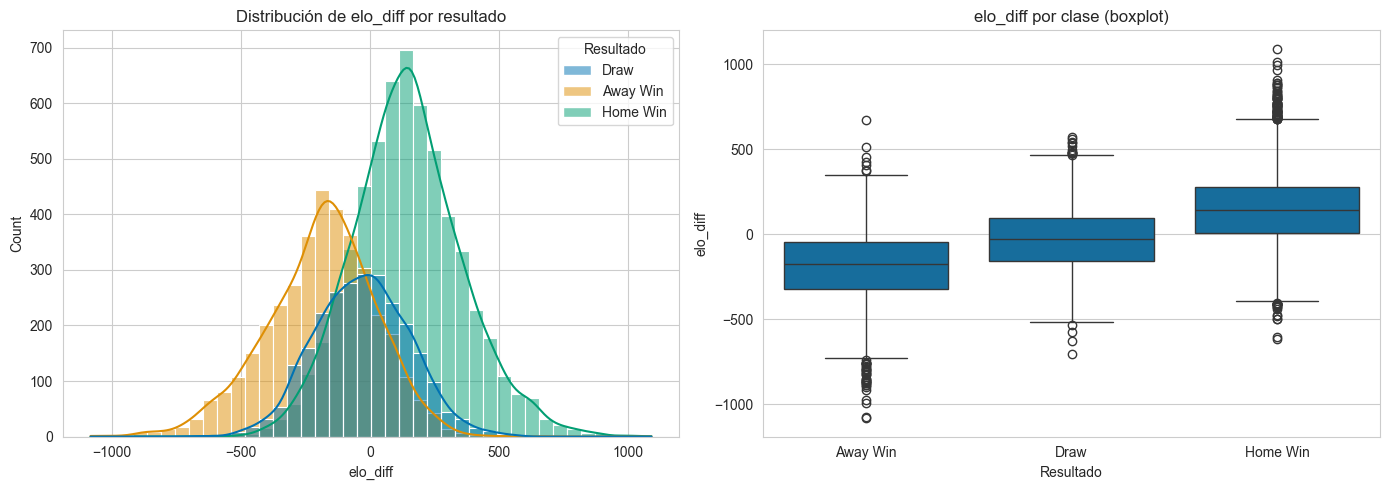

count    12157.000
mean         6.699
std        252.858
min      -1082.643
25%       -157.870
50%          9.426
75%        169.104
max       1090.792


In [13]:
plot_feature_distribution(features, 'elo_diff', 'elo_diff')

**Interpretación.**

- Rango observado [-1083, 1091] con std=252.9 y mediana=9.4 — distribución
  aproximadamente simétrica alrededor de 0. Con el ELO calculado sobre la
  historia completa, `elo_diff` ya **no arranca en 0** en los primeros partidos
  (warm-up real desde 1872), a diferencia de versiones previas.
- Las tres KDE están **claramente separadas**: el pico de Away Win se centra en
  ≈ -180, el de Draw en ≈ 0, el de Home Win en ≈ +150. Es la separación más
  limpia de las 9 features.
- Los boxplots confirman la señal monotónica: mediana Away Win ≈ -180,
  Draw ≈ -30, Home Win ≈ +120. El solapamiento es alto pero la dirección es
  robusta. Es la feature dominante en SHAP (sección 8).


### 5.2 `squad_value_diff`

  -> reports\figures\eda_05_squad_value_diff.png


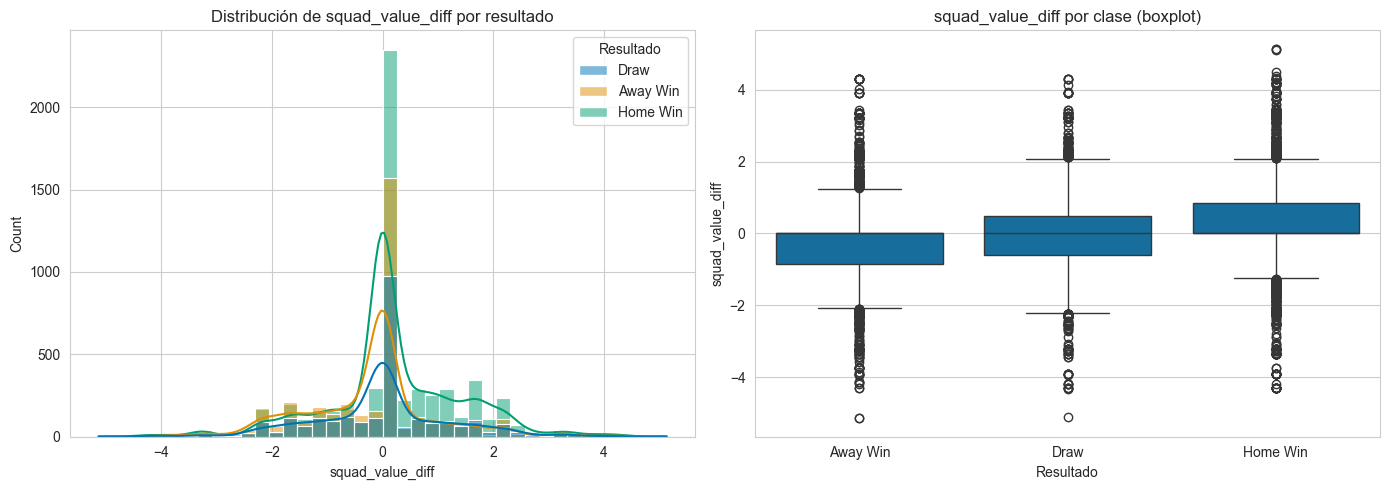

count    12157.000
mean         0.026
std          1.225
min         -5.135
25%         -0.446
50%          0.000
75%          0.533
max          5.135


In [14]:
plot_feature_distribution(features, 'squad_value_diff', 'squad_value_diff')

**Interpretación.**

- Rango [-5.14, 5.14] en escala logarítmica, std=1.23, mediana = 0. El
  histograma muestra un **pico extremo en cero**: muchos pares comparten el
  `default_val` (mediana del dataset) porque no tienen entrada en
  `_SQUAD_VALUES_EUR`. El snapshot cubre 62 equipos pero el set de
  entrenamiento incluye 217.
- La separación entre clases es **modesta**: |r| ≈ 0.14 con Home Win — unas 3.7×
  menos señal que ELO. En SHAP queda en penúltimo lugar (~0.04).
- Se mantiene porque aporta información ortogonal (capacidad económica vs. forma
  deportiva), pero es feature de segunda línea.


### 5.3 `xg_avg_for`

  -> reports\figures\eda_05_xg_avg_for.png


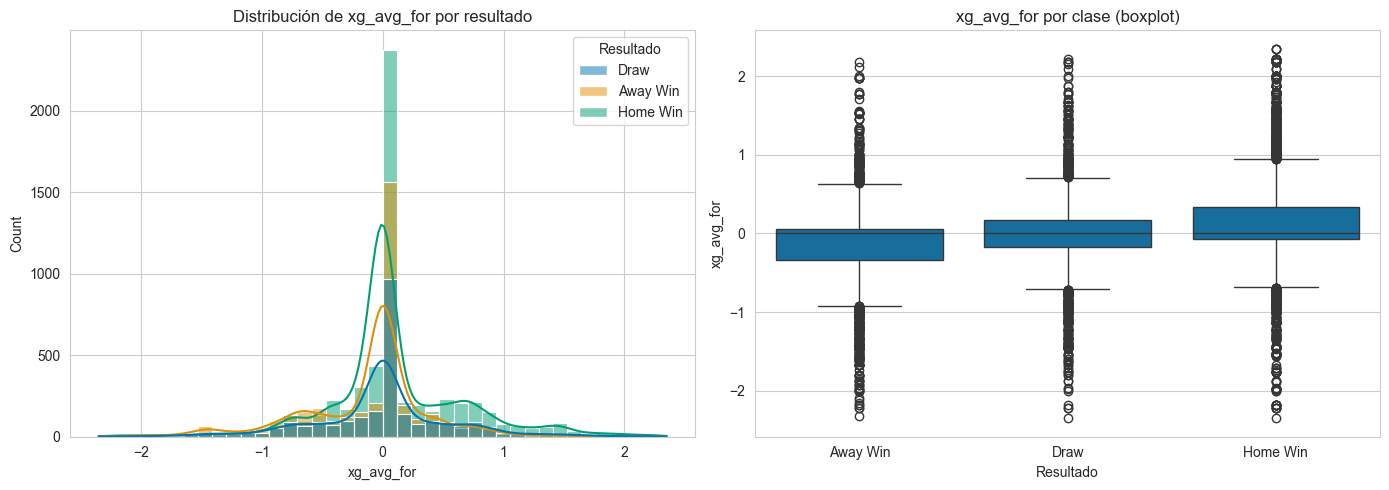

count    12157.000
mean         0.015
std          0.564
min         -2.348
25%         -0.155
50%          0.000
75%          0.172
max          2.348


In [15]:
plot_feature_distribution(features, 'xg_avg_for', 'xg_avg_for')

**Interpretación.**

- Rango [-2.35, 2.35], mediana=0, std=0.56. El pico en cero proviene de
  los equipos sin xG real en StatsBomb que reciben el `fillna(1.2)` (la
  resta de dos defaults = 0). Esto inflan la masa central artificialmente.


### 5.4 `xg_avg_against`

  -> reports\figures\eda_05_xg_avg_against.png


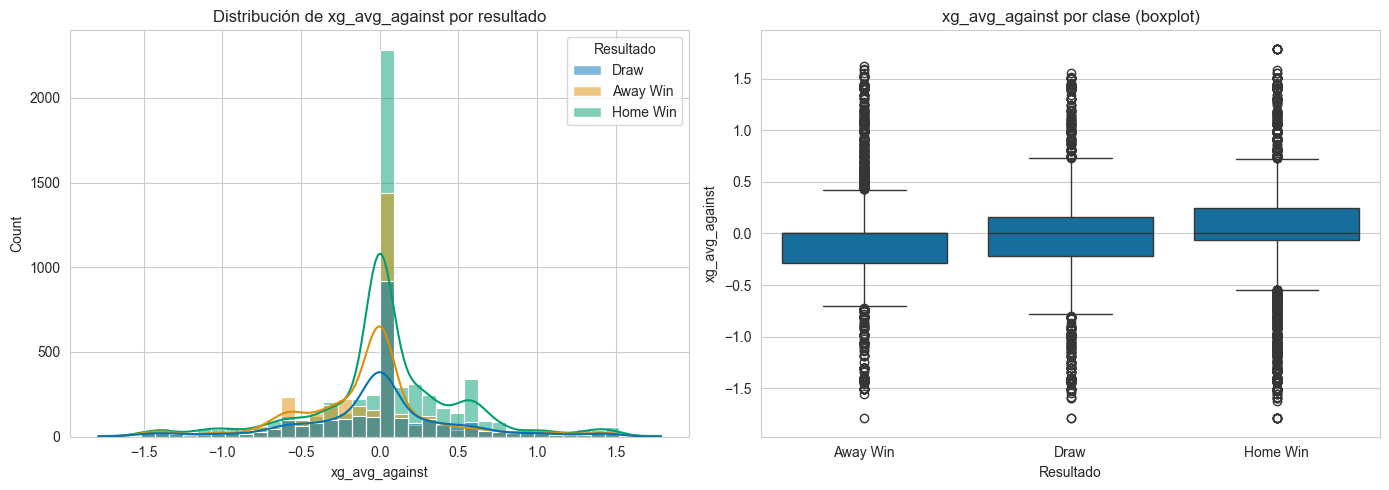

count    12157.000
mean        -0.007
std          0.493
min         -1.788
25%         -0.175
50%          0.000
75%          0.156
max          1.788


In [16]:
plot_feature_distribution(features, 'xg_avg_against', 'xg_avg_against')

### 5.5 `travel_distance_diff`

  -> reports\figures\eda_05_travel_distance_diff.png


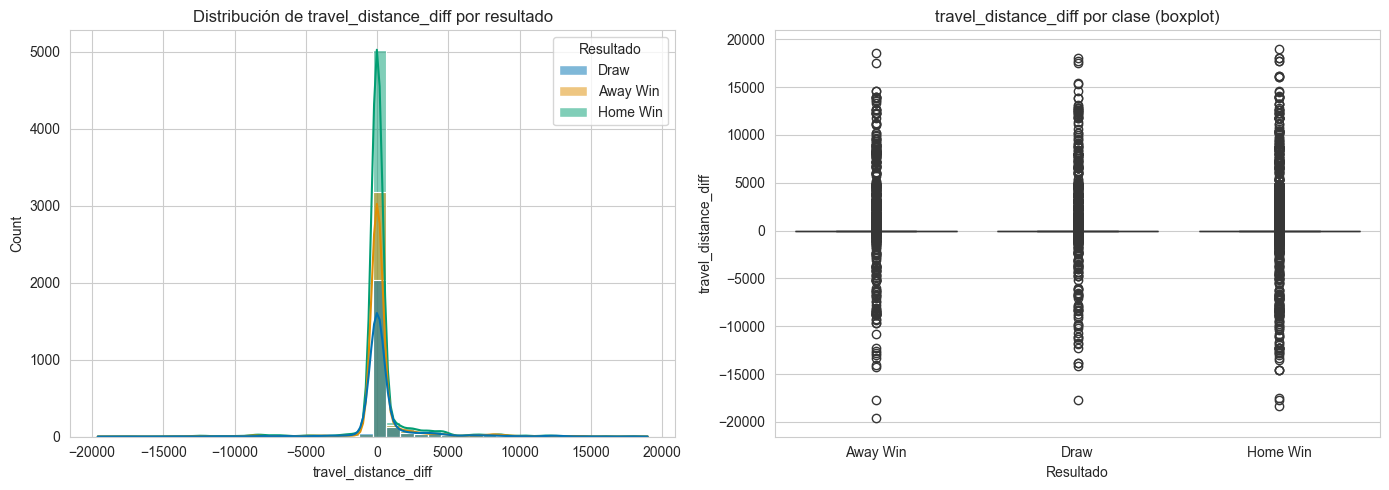

count    12157.000
mean       285.878
std       2191.650
min     -19604.070
25%          0.000
50%          0.000
75%          0.000
max      18986.618


In [17]:
plot_feature_distribution(features, 'travel_distance_diff', 'travel_distance_diff')

**Interpretación.**

- Rango [-19604, 18987] km, mediana=0, std=2192. El **82.5% de los partidos
  está en 0**: las coordenadas solo están precargadas para los 48 equipos del
  Mundial, así que los partidos históricos entre equipos fuera del torneo no se
  geocodifican (quedan en 0). Por eso los boxplots tienen IQR plano en 0.
- Donde sí hay señal (los outliers ±20.000 km), las tres clases se solapan casi
  por completo: |r| ≈ 0.02 con el target. Es la feature más débil del set.
- A diferencia de la versión vieja (`travel_distance_home`, constante 0), esta
  ya **no se anula en partidos neutrales** (corrige el caso de los Mundiales).
  Su valor real aparece en la **simulación**, donde `host_distance` está 100%
  poblado para los 48 equipos. Se mantiene y se documenta su aporte marginal en
  la ablación.


### 5.6 `ranking_diff`

  -> reports\figures\eda_05_ranking_diff.png


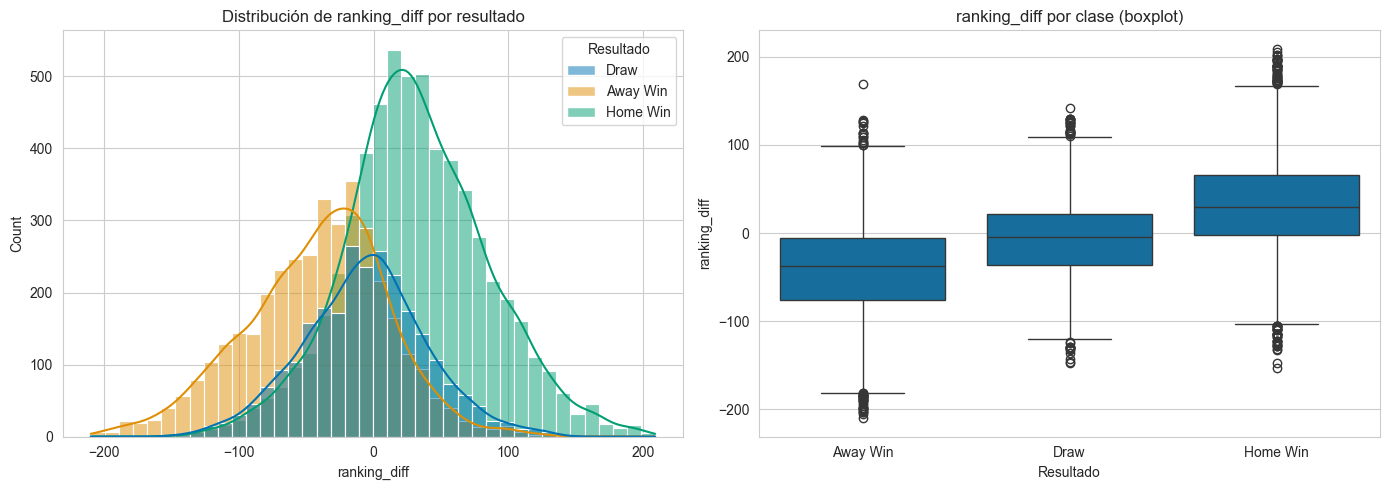

count    12157.000
mean         1.245
std         60.958
min       -210.000
25%        -36.000
50%          2.000
75%         39.000
max        209.000


In [18]:
plot_feature_distribution(features, 'ranking_diff', 'ranking_diff')

**Interpretación.**

- Rango [-210, 209] (216 equipos en el ranking FIFA → diferencia teórica
  máxima 215), std=61.0, mediana=2 → distribución casi simétrica.
- Las tres KDE están separadas con el mismo patrón que ELO: Away Win a la
  izquierda, Home Win a la derecha. |r| ≈ 0.49 con Home Win, casi igual a ELO.
- La sección 6 muestra que `elo_diff` y `ranking_diff` están **muy
  correlacionados (r = 0.88)**, lo que abre la pregunta de redundancia. La
  sección 8 (SHAP) la responde: `ranking_diff` mantiene mean|SHAP| ~0.25, así
  que el modelo lo usa activamente. **No son redundantes**: el ELO actualiza
  partido a partido ponderando margen y K-factor por torneo; el ranking FIFA
  acumula puntos con menor sensibilidad a partidos individuales.


### 5.7 Features derivadas de eventos (as-of-date)

Tres features se calculan de `goalscorers.csv` y `shootouts.csv` de forma
estrictamente *as-of-date* (`merge_asof(backward, allow_exact_matches=False)`),
es decir, cada partido solo ve eventos anteriores a su fecha (sin leakage). Se
muestran como diff `home − away`:

- `penalty_share_diff` — proporción de goles de penal.
- `striker_concentration_diff` — Herfindahl de goleadores (dependencia de una figura).
- `shootout_winrate_diff` — winrate en tandas con shrinkage Bayes (prior 0.5).

  -> reports\figures\eda_05_penalty_share_diff.png


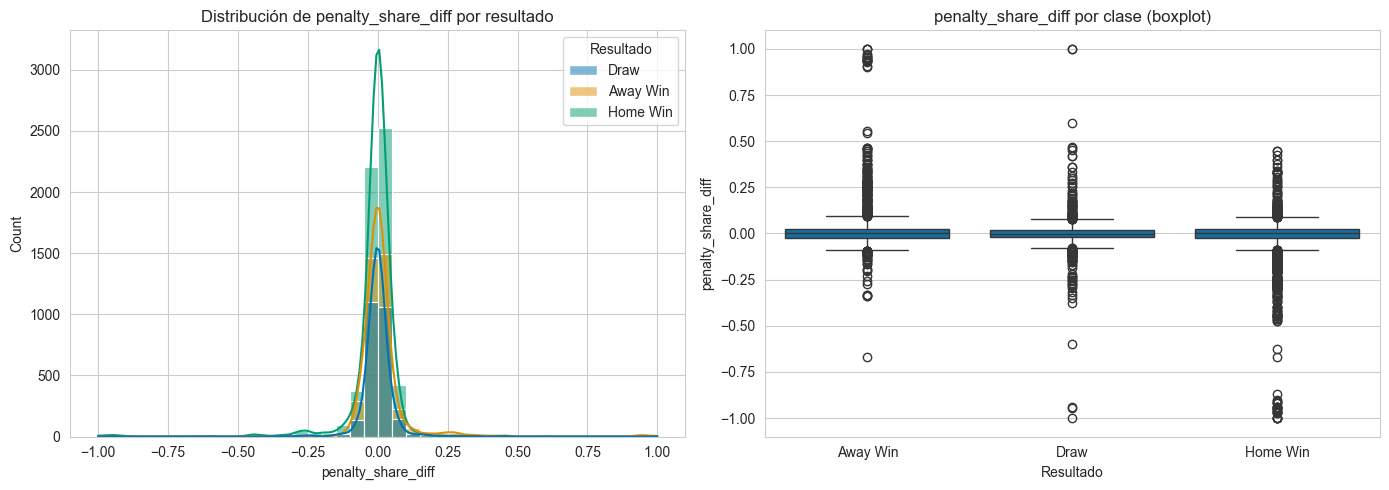

count    12157.000
mean        -0.000
std          0.088
min         -1.000
25%         -0.022
50%          0.000
75%          0.022
max          1.000


In [19]:
plot_feature_distribution(features, 'penalty_share_diff', 'penalty_share_diff')

  -> reports\figures\eda_05_striker_concentration_diff.png


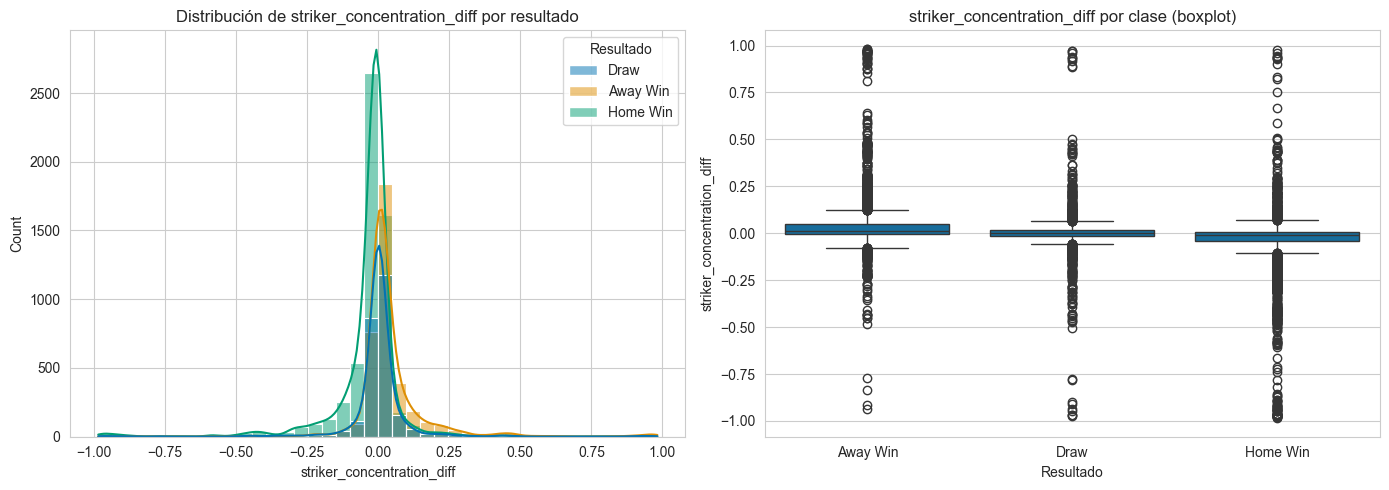

count    12157.000
mean        -0.003
std          0.130
min         -0.985
25%         -0.020
50%         -0.001
75%          0.019
max          0.982


In [20]:
plot_feature_distribution(features, 'striker_concentration_diff', 'striker_concentration_diff')

  -> reports\figures\eda_05_shootout_winrate_diff.png


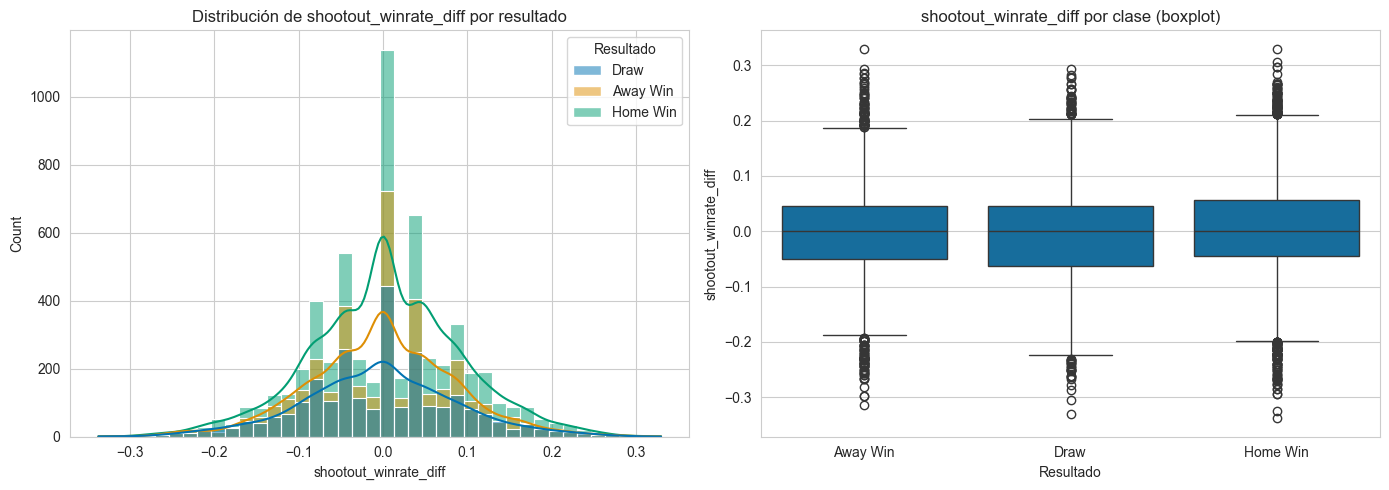

count    12157.000
mean         0.000
std          0.089
min         -0.338
25%         -0.051
50%          0.000
75%          0.052
max          0.330


In [21]:
plot_feature_distribution(features, 'shootout_winrate_diff', 'shootout_winrate_diff')

**Interpretación (features derivadas).**

- **`striker_concentration_diff`** es la sorpresa positiva: |r| ≈ **0.23** con el
  target (3ª más correlacionada, tras ELO y ranking) y **2ª en SHAP (~0.36)**.
  El signo es **negativo**: cuando el local depende menos de un solo goleador
  (Herfindahl más bajo que el rival), gana más. Coherente con la sección 6,
  donde correlaciona -0.36/-0.37 con ELO/ranking: los equipos fuertes reparten
  más el goleo. El boxplot lo muestra (mediana Away ≈ +0.02, Home ≈ -0.02). Es
  la feature que justifica haber traído `goalscorers.csv`.
- **`penalty_share_diff`**: std=0.088, |r| ≈ 0.10 (negativo). Aporte modesto
  (SHAP ~0.12, 4º). Casi sin ceros (1.7%) porque casi todo equipo tiene algún
  penal en su historia.
- **`shootout_winrate_diff`**: std=0.089, |r| ≈ 0.035 — **la más débil de las
  tres**. El shrinkage Bayes (prior 0.5) deja a las potencias grandes en ~0.5
  (16.7% de ceros), así que la señal se concentra en selecciones con muchas
  tandas. Se mantiene pero su aporte es marginal (SHAP ~0.09); la ablación lo
  documenta.


### 5.8 `time_weight` — decay exponencial

Half-life del decay con lambda=0.001: 1.90 años


  -> reports\figures\eda_05_time_weight.png


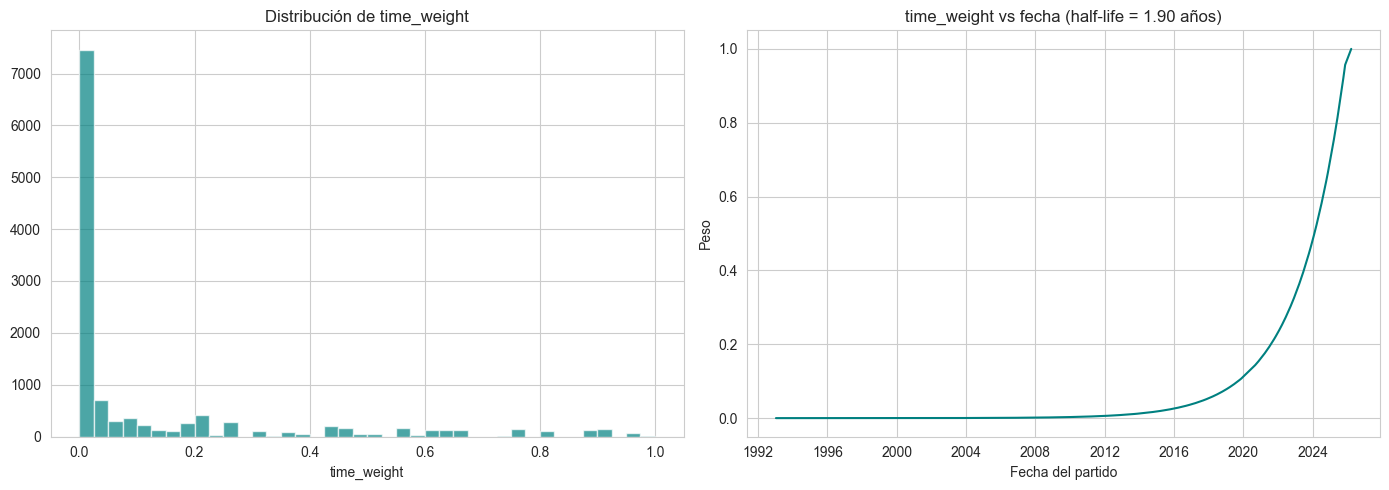

In [22]:
halflife = lambda_to_halflife_years(DEFAULT_LAMBDA)
print(f"Half-life del decay con lambda={DEFAULT_LAMBDA:.3f}: {halflife:.2f} años")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(features['time_weight'], bins=40, color='teal', alpha=0.7)
axes[0].set_title("Distribución de time_weight")
axes[0].set_xlabel("time_weight")

# Serie temporal
sample = features.sort_values('date').iloc[::max(1, len(features)//500)]
axes[1].plot(sample['date'], sample['time_weight'], color='teal')
axes[1].set_title(f"time_weight vs fecha (half-life = {halflife:.2f} años)")
axes[1].set_xlabel("Fecha del partido")
axes[1].set_ylabel("Peso")

plt.tight_layout()
savefig("05_time_weight")
plt.show()


**Análisis del decay.**

- Half-life calculado: **1.90 años**. Significa que un partido de hace ~2
  años pesa la mitad que uno reciente; uno de hace 5 años pesa
  ≈ 16% del peso de uno reciente.
- El histograma muestra una **acumulación hacia pesos bajos**, pero ya no
  tan extrema: los partidos muy antiguos pesan poco sin quedar prácticamente
  en cero.
- La serie temporal muestra el crecimiento exponencial desde 0 hasta 1
  acercándose a `REFERENCE_DATE = 2026-01-01`. Los partidos posteriores a
  esa fecha (los hay, hasta 2026-06) reciben peso 1.0 por el `clip(lower=0)`.
- **Implicación**: λ = 0.001 es más moderado. Refleja cambios recientes sin
  borrar casi toda la señal histórica. Si el modelo sobre-reacciona a lo
  histórico, λ debería subir; si falta señal histórica, bajar.


## 6. Correlaciones


  -> reports\figures\eda_06_correlation_matrix.png


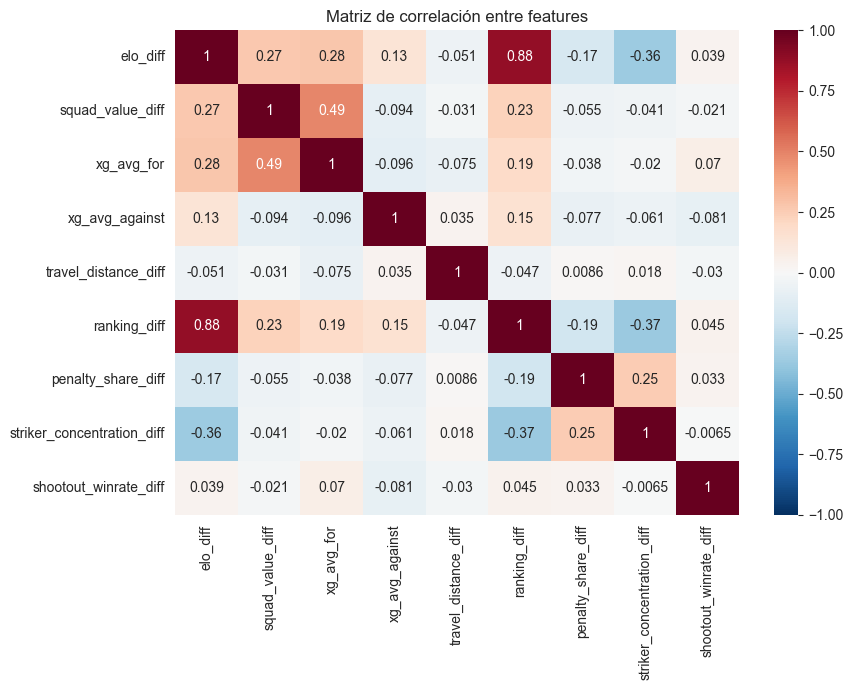

In [23]:
corr = features[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación entre features")
plt.tight_layout()
savefig("06_correlation_matrix")
plt.show()


**Hallazgos del heatmap (valores reales).**

| Par | r | Lectura |
|---|---|---|
| `elo_diff` ↔ `ranking_diff` | **0.88** | Alta colinealidad — ambos miden fuerza relativa. |
| `squad_value_diff` ↔ `xg_avg_for` | **0.49** | Plantillas más valiosas generan más xG ofensivo. |
| `ranking_diff` ↔ `striker_concentration_diff` | **-0.37** | Equipos fuertes **reparten más el goleo** (menor Herfindahl). |
| `elo_diff` ↔ `striker_concentration_diff` | **-0.36** | Mismo efecto con ELO. |
| `penalty_share_diff` ↔ `striker_concentration_diff` | 0.25 | Equipos dependientes de una figura concentran también los penales. |
| `elo_diff` ↔ `xg_avg_for` / `squad_value_diff` | 0.28 / 0.27 | ELO captura algo de calidad ofensiva y económica. |
| `travel_distance_diff` ↔ resto | < 0.05 | Ortogonal — coherente con 82.5% de ceros. |
| `shootout_winrate_diff` ↔ resto | < 0.08 | Prácticamente independiente del resto. |

**Decisión sobre `elo_diff` vs `ranking_diff`**: la colinealidad de 0.88 es alta
pero **no estricta** (1.0). Mantener ambos está justificado y lo valida SHAP
(sección 8): `ranking_diff` conserva mean|SHAP| ~0.25. El hallazgo más relevante
es que `striker_concentration_diff` es **anti-correlacionada con la fuerza** y
aun así la más informativa de las derivadas — captura un eje (estructura del
ataque) ortogonal al nivel del equipo.

In [24]:
# Correlación con target (point-biserial vs cada clase)
from scipy.stats import pointbiserialr
rows = []
for cls in [0, 1, 2]:
    y = (features['target'] == cls).astype(int)
    for feat in FEATURE_COLS:
        r, p = pointbiserialr(features[feat].fillna(0), y)
        rows.append({"feature": feat, "clase": target_map[cls],
                     "r": round(r, 3), "p_value": round(p, 5)})
corr_target = pd.DataFrame(rows).pivot(index='feature', columns='clase', values='r')
corr_target


clase,Away Win,Draw,Home Win
feature,,,
elo_diff,-0.517,-0.074,0.536
penalty_share_diff,0.096,0.003,-0.091
ranking_diff,-0.471,-0.065,0.487
shootout_winrate_diff,-0.014,-0.027,0.035
squad_value_diff,-0.138,-0.019,0.143
striker_concentration_diff,0.231,0.025,-0.233
travel_distance_diff,0.003,0.024,-0.023
xg_avg_against,-0.092,-0.008,0.091
xg_avg_for,-0.158,-0.015,0.159


**Lectura del point-biserial features↔target.**

Ranking de features por |r| máximo con cualquier clase (valores observados):

1. `elo_diff` — |r| hasta **0.536** (Home Win).
2. `ranking_diff` — **0.487**.
3. `striker_concentration_diff` — **0.233** (signo negativo).
4. `xg_avg_for` — 0.159.
5. `squad_value_diff` — 0.143.
6. `penalty_share_diff` — 0.096.
7. `xg_avg_against` — 0.092.
8. `shootout_winrate_diff` — 0.035.
9. `travel_distance_diff` — **0.024** (prácticamente ruido).

La clase **Draw** recibe |r| ≈ 0.003–0.074 en todas las features (mucho menor
que Home/Away). Las features discriminan bien Home vs Away pero el **empate
queda subdeterminado** — esto reaparece en las curvas de calibración del modelo.


  -> reports\figures\eda_06_pairplot.png


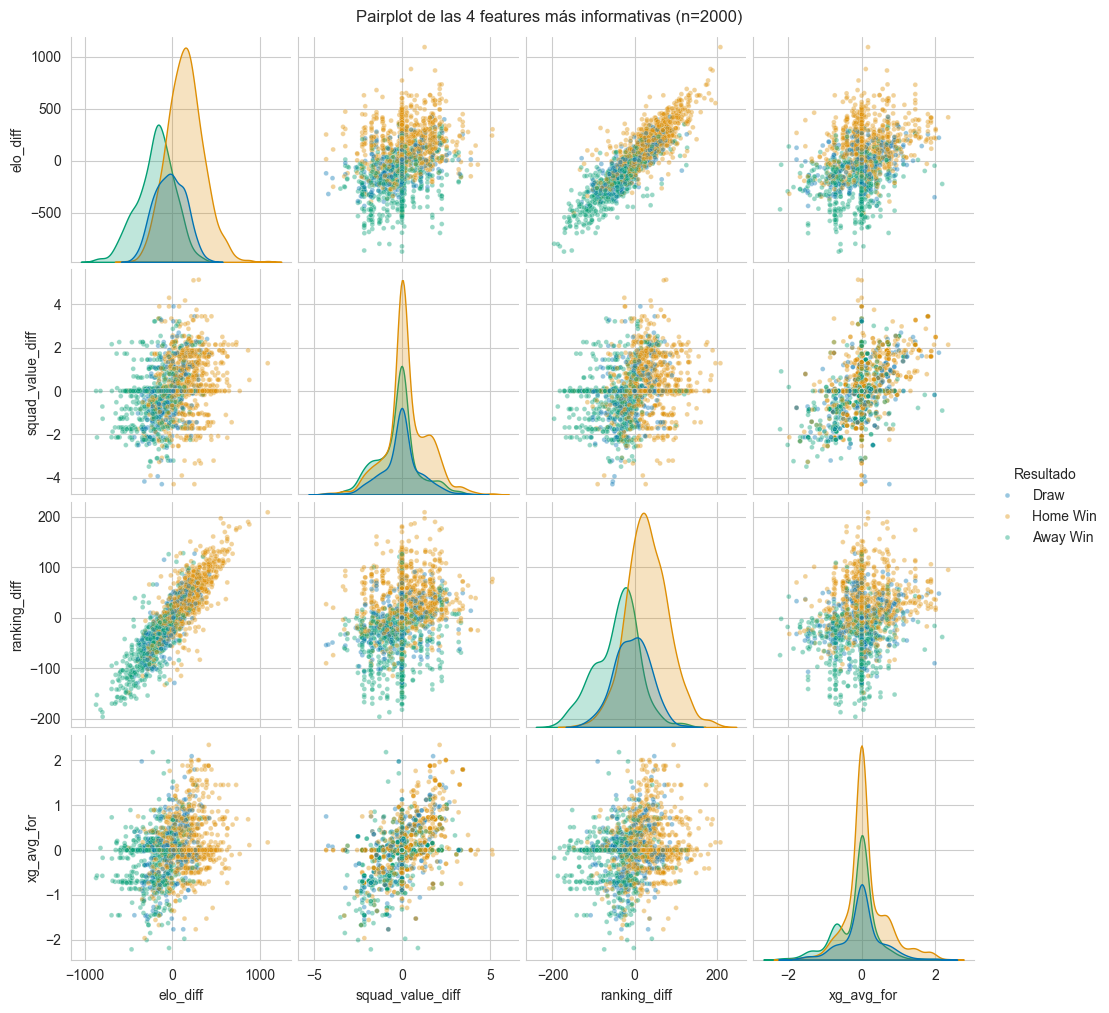

In [25]:
# Pairplot reducido (sample para velocidad)
sample = features.sample(min(2000, len(features)), random_state=42).copy()
sample['Resultado'] = sample['target'].map(target_map)
selected = ['elo_diff', 'squad_value_diff', 'ranking_diff', 'xg_avg_for']
g = sns.pairplot(sample[selected + ['Resultado']], hue='Resultado',
                 diag_kind='kde', height=2.5, plot_kws={"alpha": 0.4, "s": 12})
g.fig.suptitle("Pairplot de las 4 features más informativas (n=2000)", y=1.01)
savefig("06_pairplot")
plt.show()


**Pairplot.** El scatter `elo_diff` vs `ranking_diff` muestra una nube alineada
con la diagonal — visualización directa del r=0.88. Los gradientes de color
(Away→Draw→Home) son monotónicos en ambos ejes, confirmando que cualquiera sirve
como predictor primario. Las combinaciones con `squad_value_diff` y `xg_avg_for`
muestran nubes más difusas, con separación de clases mucho más sutil.


## 7. ELO histórico


In [26]:
from src.features.elo import calculate_elo_ratings

# ELO sobre el UNIVERSO COMPLETO (todos los torneos incl. amistosos, toda la
# historia), igual que el pipeline. No se filtra: el ELO necesita la historia
# completa para estar bien calibrado.
elo_df = calculate_elo_ratings(results_raw.sort_values("date"))
print(f"ELO records: {len(elo_df):,} | rango {elo_df['date'].min().date()} - {elo_df['date'].max().date()}")
elo_df.tail(5)



ELO:   0%|          | 0/49329 [00:00<?, ?match/s]


ELO:  38%|███▊      | 18603/49329 [00:00<00:00, 186015.10match/s]


ELO:  97%|█████████▋| 47956/49329 [00:00<00:00, 249244.63match/s]


ELO: 100%|██████████| 49329/49329 [00:00<00:00, 240215.05match/s]

ELO records: 49,257 | rango 1872-11-30 - 2026-03-31


,date,home_team,away_team,home_elo_before,away_elo_before,home_elo_after,away_elo_after
49252,2026-03-31,Kosovo,Turkey,1779.078496,1908.535966,1759.766634,1927.847828
49253,2026-03-31,Cameroon,China,1662.054838,1568.744972,1674.964740,1555.835069
49254,2026-03-31,Australia,Curacao,1866.847571,1598.940972,1873.015149,1592.773394
49255,2026-03-31,United States,Portugal,1840.559545,1936.786354,1833.260465,1944.085435
49256,2026-03-31,Russia,Mali,1815.140512,1652.259062,1810.768134,1656.631439


  -> reports\figures\eda_07_elo_history.png


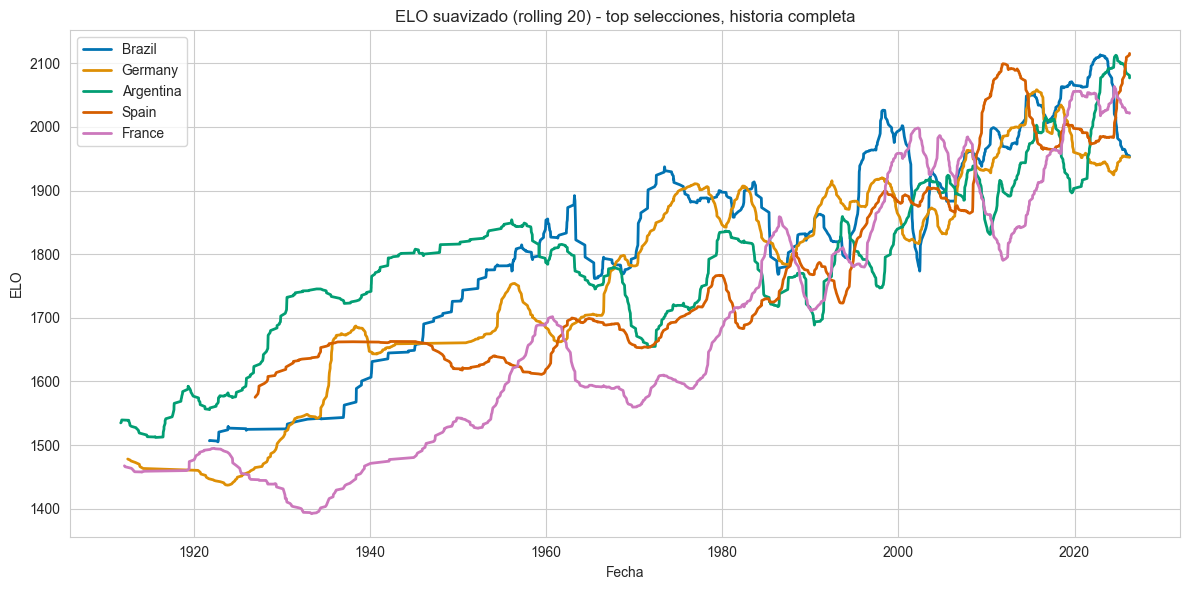

In [27]:
# ELO en el tiempo para 5 selecciones icónicas (historia completa)
icons = ["Brazil", "Germany", "Argentina", "Spain", "France"]
fig, ax = plt.subplots(figsize=(12, 6))
for team in icons:
    h = elo_df[elo_df['home_team'] == team][['date', 'home_elo_after']].rename(
        columns={'home_elo_after': 'elo'})
    a = elo_df[elo_df['away_team'] == team][['date', 'away_elo_after']].rename(
        columns={'away_elo_after': 'elo'})
    series = pd.concat([h, a]).sort_values('date')
    if not series.empty:
        ax.plot(series['date'], series['elo'].rolling(20).mean(), label=team, linewidth=2)
ax.legend()
ax.set_title("ELO suavizado (rolling 20) - top selecciones, historia completa")
ax.set_xlabel("Fecha"); ax.set_ylabel("ELO")
plt.tight_layout()
savefig("07_elo_history")
plt.show()


- Con el ELO sobre la **historia completa**, las cinco trayectorias arrancan
  cerca de `INITIAL_RATING=1500` a inicios del s. XX y suben de forma sostenida
  hasta la franja **1900–2150** en los 2020s, reflejando la profesionalización
  y la acumulación de partidos.
- **España** sube fuerte en su era dorada (Euro 2008 / Mundial 2010 / Euro 2012)
  y vuelve a la cima en 2022–2026, terminando como **#1 del ELO (2137)**.
- **Argentina** muestra un valle ~2010 y una subida pronunciada hacia el Mundial
  2022, cerrando 2º (2046). **Francia** mantiene perfil alto desde 2018 (3º,
  2040).
- **Alemania** tiene un perfil alto y estable hasta 2014 y una caída desde 2018
  (eliminaciones tempranas), cayendo a la mitad baja del top-10 (1949).
- **Brasil** se mantiene en la franja 1850–2000 pero, notablemente, **queda
  fuera del top-10 ELO** al cierre — el ELO (basado en resultados recientes) lo
  penaliza más que el ranking FIFA, donde sí aparece (ver celda siguiente).


In [28]:
# Top-10 ELO al REFERENCE_DATE
home_last = elo_df.groupby("home_team")["home_elo_after"].last()
away_last = elo_df.groupby("away_team")["away_elo_after"].last()
last_elo = pd.concat([home_last.rename("elo"), away_last.rename("elo")])
last_elo = last_elo.groupby(last_elo.index).last().sort_values(ascending=False)
top10_elo = last_elo.head(10).round(0).reset_index()
top10_elo.columns = ["team", "elo"]
print("Top-10 ELO al final del dataset:")
print(top10_elo.to_string(index=False))


Top-10 ELO al final del dataset:
       team    elo
      Spain 2137.0
  Argentina 2046.0
     France 2040.0
    England 2013.0
    Germany 1949.0
    Ecuador 1946.0
   Portugal 1944.0
      Japan 1939.0
Netherlands 1933.0
   Colombia 1932.0


In [29]:
# Top-10 FIFA al snapshot más reciente (2026-05-30), el mismo que usa la simulación
fifa_at_ref = fifa[fifa['rank_date'] <= SNAPSHOT_DATE].sort_values('rank_date')
latest_fifa = fifa_at_ref.groupby('team').last().sort_values('rank').head(10)
print(f"Top-10 ranking FIFA al {SNAPSHOT_DATE.date()}:")
print(latest_fifa[['rank', 'total_points']].to_string())


Top-10 ranking FIFA al 2026-05-30:
             rank  total_points
team                           
France        1.0       1877.32
Spain         2.0       1876.40
Argentina     3.0       1874.81
England       4.0       1825.97
Portugal      5.0       1763.83
Brazil        6.0       1761.16
Netherlands   7.0       1757.87
Morocco       8.0       1755.87
Belgium       9.0       1734.71
Germany      10.0       1730.37


**ELO (fin del dataset) vs FIFA (snapshot 2026-05-30) — divergencias.**

| Pos | Top-10 ELO | Top-10 FIFA |
|---:|---|---|
| 1 | Spain (2137) | France |
| 2 | Argentina (2046) | Spain |
| 3 | France (2040) | Argentina |
| 4 | England (2013) | England |
| 5 | Germany (1949) | Portugal |
| 6 | Ecuador (1946) | Brazil |
| 7 | Portugal (1944) | Netherlands |
| 8 | Japan (1939) | Morocco |
| 9 | Netherlands (1933) | Belgium |
| 10 | Colombia (1932) | Germany |

**Intersección de 7 equipos** (Spain, Argentina, France, England, Germany,
Portugal, Netherlands) y **3 divergencias por lado**:

- ELO incluye y FIFA no: **Ecuador, Japan, Colombia** — selecciones con buenos
  resultados recientes que el ELO premia, pero a las que el sistema de puntos
  FIFA aún no posiciona en el top.
- FIFA incluye y ELO no: **Brazil, Morocco, Belgium** — conservan inercia en el
  ranking acumulado pese a un rendimiento reciente que el ELO penaliza más.

El top-3 coincide en ambos (Spain/France/Argentina), solo cambia el orden —
ELO pone a España 1ª (era dorada reciente), FIFA a Francia 1ª (puntos acumulados).


## 8. SHAP — importancia agregada de features


In [30]:
from pathlib import Path
model_path = Path("data/processed/models/xgboost.joblib")

if model_path.exists():
    from src.models.train import load_model
    model = load_model("xgboost")
    print("Modelo XGBoost cargado.")
else:
    model = None
    print("Modelo no disponible — ejecuta `make train` primero. Saltando SHAP.")


Modelo XGBoost cargado.


  -> reports\figures\eda_08_shap_summary.png


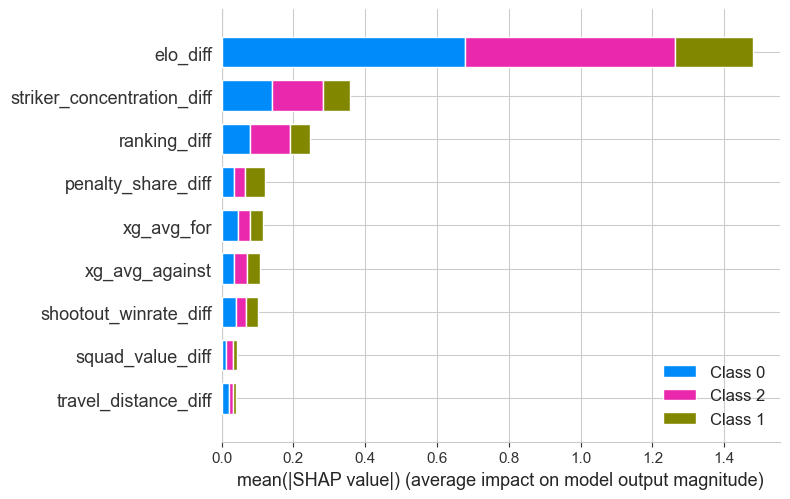

In [31]:
if model is not None:
    import shap
    X_sample = features[FEATURE_COLS].sample(2000, random_state=42).astype(np.float32)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_sample, check_additivity=False)
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS, show=False)
    plt.tight_layout()
    savefig("08_shap_summary")
    plt.show()
else:
    print("(omitido)")


**Ranking SHAP observado (mean |SHAP value|, sumado sobre las 3 clases).**

| # | Feature | mean\|SHAP\| | Lectura |
|---:|---|---:|---|
| 1 | `elo_diff` | **~1.48** | Dominante — ~4× el siguiente. |
| 2 | `striker_concentration_diff` | **~0.36** | **2ª feature** — la estructura del ataque (dependencia de una figura) es muy informativa, ortogonal al nivel del equipo. |
| 3 | `ranking_diff` | ~0.25 | No redundante con ELO pese a r=0.88: corrección sobre la fuerza acumulada. |
| 4 | `penalty_share_diff` | ~0.12 | Aporte modesto pero consistente. |
| 5 | `xg_avg_for` | ~0.11 | Eficiencia ofensiva. |
| 6 | `xg_avg_against` | ~0.10 | Solidez defensiva. |
| 7 | `shootout_winrate_diff` | ~0.09 | Marginal — señal concentrada en equipos con muchas tandas. |
| 8 | `squad_value_diff` | ~0.04 | Diluida por snapshot manual + fallback a mediana. |
| 9 | `travel_distance_diff` | **~0.03** | Mínimo — coherente con el 82.5% de ceros en entrenamiento. |

**Decisiones derivadas:**

1. **`striker_concentration_diff` es la mejor adición** de los datos de eventos:
   2ª en SHAP y |r|=0.23. Justifica integrar `goalscorers.csv`.
2. **No eliminar `ranking_diff`**: mean|SHAP| ~0.25 confirma uso activo pese a la
   colinealidad con ELO.
3. **`travel_distance_diff`, `squad_value_diff` y `shootout_winrate_diff` son de
   aporte marginal** — se mantienen pero se documentan con filas propias en el
   estudio de ablación (`ablation.py`).
4. **Draw sigue siendo la clase difícil**: todas las features aportan poco a
   discriminar empates (|r| < 0.08, sección 6), lo que se refleja en la
   calibración del modelo.


## 9. Limitaciones cuantificadas del dataset


In [32]:
from src.simulation.tournament import GROUPS_2026, ALL_TEAMS

# Partidos por equipo, restringido a equipos del WC 2026
wc26_counts = team_counts.reindex(ALL_TEAMS).fillna(0).astype(int)
print("Equipos WC 2026 con MENOS partidos históricos (post-1990):")
print(wc26_counts.sort_values().head(10).to_string())
print(f"\nMediana: {int(wc26_counts.median())} partidos")


Equipos WC 2026 con MENOS partidos históricos (post-1990):
Cape Verde      53
New Zealand     61
Curacao         65
DR Congo        76
Senegal         83
Haiti           84
Ivory Coast     84
South Africa    84
Algeria         87
Egypt           88

Mediana: 200 partidos


In [33]:
# Cobertura xG sobre equipos del Mundial
xg_teams = set(xg['team']) if not xg.empty else set()
in_xg = [t for t in ALL_TEAMS if t in xg_teams]
miss_xg = [t for t in ALL_TEAMS if t not in xg_teams]
print(f"Cobertura xG StatsBomb sobre 48 equipos WC2026: {len(in_xg)}/48 = {len(in_xg)/48*100:.1f}%")
print(f"  Equipos sin xG real (usan 1.2 default): {miss_xg[:15]}{' ...' if len(miss_xg) > 15 else ''}")


Cobertura xG StatsBomb sobre 48 equipos WC2026: 35/48 = 72.9%
  Equipos sin xG real (usan 1.2 default): ['South Africa', 'Bosnia & Herzegovina', 'Haiti', 'Curacao', 'Ivory Coast', 'New Zealand', 'Cape Verde', 'Iraq', 'Norway', 'Algeria', 'Jordan', 'DR Congo', 'Uzbekistan']


In [34]:
# Cobertura squad_value
sv_teams = set(squad['team'])
in_sv = [t for t in ALL_TEAMS if t in sv_teams]
miss_sv = [t for t in ALL_TEAMS if t not in sv_teams]
print(f"Cobertura squad_value sobre 48 equipos WC2026: {len(in_sv)}/48 = {len(in_sv)/48*100:.1f}%")
print(f"  Equipos sin valor (usan mediana): {miss_sv}")


Cobertura squad_value sobre 48 equipos WC2026: 48/48 = 100.0%
  Equipos sin valor (usan mediana): []


**Limitaciones numéricas medidas (no asumidas).**

**1. Equipos del WC2026 con escaso historial post-1993 (mediana del grupo = 200):**

| Equipo | # partidos | Δ vs mediana |
|---|---:|---:|
| Cape Verde | 53 | -147 |
| New Zealand | 61 | -139 |
| Curacao | 65 | -135 |
| DR Congo | 76 | -124 |
| Senegal | 83 | -117 |
| Haiti | 84 | -116 |
| Ivory Coast | 84 | -116 |
| South Africa | 84 | -116 |
| Algeria | 87 | -113 |
| Egypt | 88 | -112 |

Para estos equipos el ELO tiene mayor varianza (menos datos para alejarse del
`INITIAL_RATING=1500`), aunque el uso de la historia completa (incl. amistosos)
mitiga parcialmente el problema. Cabe esperar peor calibración cuando jueguen.

**2. Cobertura xG StatsBomb sobre los 48 del Mundial: 35/48 = 72.9%.**

Los **13 equipos sin xG real** (reciben `xg_for = xg_against = 1.2` por default):
South Africa, Bosnia & Herzegovina, Haiti, Curacao, Ivory Coast, New Zealand,
Cape Verde, Iraq, Norway, Algeria, Jordan, DR Congo, Uzbekistan. Coincide en
gran parte con la lista de "pocos partidos": para ellos `xg_avg_*` es ruido.

**3. Cobertura `squad_value`: 48/48 = 100%.** El snapshot manual cubre todos los
clasificados, así que esta feature no sufre cobertura desigual (sí el anacronismo
de ser un valor estático aplicado a toda la historia — ver README/ablación).

**4. `travel_distance_diff`: 82.5% de los partidos en 0.** No es un bug sino la
consecuencia de que las coordenadas solo están precargadas para los 48 equipos
del Mundial; los partidos históricos entre otros equipos no se geocodifican.
SHAP la confirma como la feature de menor aporte. Para la simulación del WC2026
el equivalente es `host_distance` en `team_features`, **100% poblado** (distancia
a sedes USA/MEX/CAN). Para cobertura histórica completa se puede ejecutar
`features.py` con `USE_NOMINATIM=1`.
